# MNIST Classification

🎯 <b><u>Exercise objectives</u></b>
- Understanding the *MNIST* dataset
- Designing your first **Convolutional Neural Network** (*CNN*) and answering:
    - What are *convolution layers*?
    - How many *parameters* are in such a layer?
- Training this CNN on images

🚀 <b><u>Let's get started!</u></b>

Imagine we travel back to the 1990s.
You work at a *post office* and every day you must handle a huge volume of mail. How could you automate reading **ZIP codes**—combinations of five handwritten digits?

This task, called **handwriting recognition**, was very hard back then. It was tackled at *Bell Labs* (among others), where one of the pioneers of deep learning, [*Yann LeCun*](https://en.wikipedia.org/wiki/Yann_LeCun), worked.

From [Wikipedia](https://en.wikipedia.org/wiki/Handwriting_recognition):

> Handwriting recognition (HWR), also known as handwritten text recognition (HTR), is the ability of a computer to receive and interpret intelligible handwritten input from sources such as paper documents, photographs, touchscreens, and other devices.

![Digit recognition](recognition.gif)

*Note: The animation above is only here to help you visualize what happens with different images: <br/> $\rightarrow$ For each image, after the CNN is trained, it will predict which digit was written. The inputs are different digits—not a single animation/video!*

🤔 <b><u>How does this CNN work?</u></b>

- *Inputs*: Images (_each image shows a handwritten digit_)
- *Goal*: For each image, you want your CNN model to predict the correct digit (between 0 and 9)
    - This is a **multiclass classification** task (more precisely, 10-class classification because there are 10 distinct digits).

🔢 To help the convolutional neural network learn to read these digits, you must feed it many images representing handwritten digits. That is why the 📚 [**MNIST dataset**](http://yann.lecun.com/exdb/mnist/) *(Modified National Institute of Standards and Technology)* was created.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## (1) The `MNIST` dataset

📚 TensorFlow/Keras provides several [**datasets**](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) to experiment with:
- *Vectors*: `boston_housing` (regression)
- *Images*: `mnist`, `fashion_mnist`, `cifar10`, `cifar100` (classification)
- *Text*: `imdb`, `reuters` (classification / sentiment analysis)


💾 You can **load the MNIST dataset** with the commands below:

In [2]:
from keras import datasets


# Loading the MNIST Dataset...
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data(path="mnist.npz")

# The train set contains 60 000 images, each of them of size 28x28
# The test set contains 10 000 images, each of them of size 28x28
(X_train.shape, y_train.shape), (X_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(((60000, 28, 28), (60000,)), ((10000, 28, 28), (10000,)))

### (1.1) Exploring the dataset

❓ **Question: Let's look at some handwritten digits from this MNIST dataset.** ❓

🖨 Display some images from the *training set*.

<details>
    <summary><i>Hints</i></summary>

💡 *Hint*: use `imshow` from `matplotlib` with `cmap="gray"`

🤨 Note: if you omit this *cmap* argument, the odd-looking colors are just Matplotlib defaults...
    
</details>

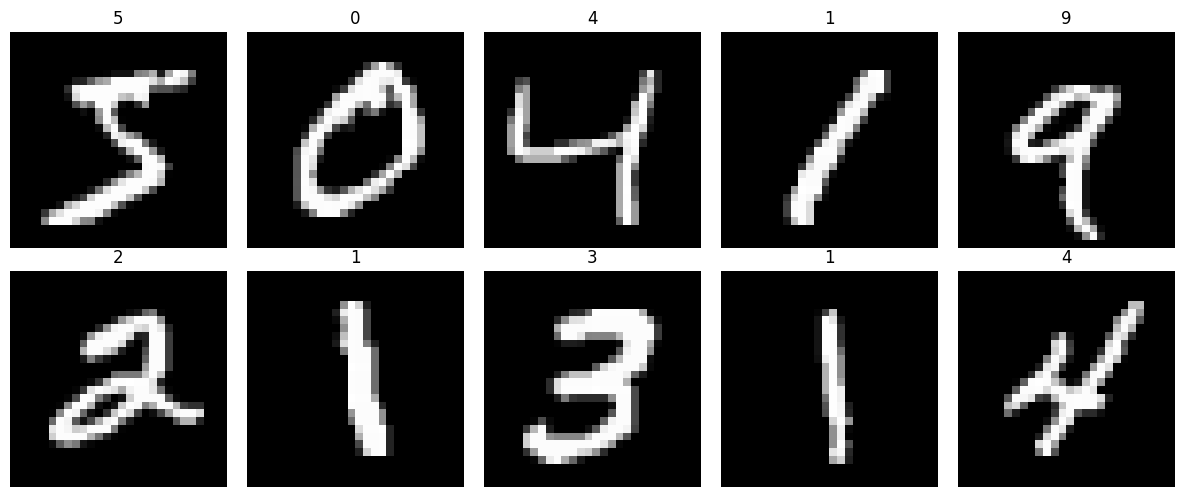

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, image, label in zip(axes.flat, X_train[:10], y_train[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"{label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### (1.2) Image preprocessing

❗️ **Neural networks converge faster when the input data is normalized in some way** ❗️

👩🏻‍🏫 How do we proceed for convolutional neural networks?
* Intensities are often encoded between 0 and 255.
* By dividing the input by the maximum value 255, we can keep all pixel intensities between 0 and 1 😉

❓ **Question ❓ As a first preprocessing step, please normalize your data.**

Do not forget to apply this to both your training and test data.

(*Note: you may also center the data by subtracting 0.5 from all values, but that is optional*)

In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

### (1.3) Input shapes

In [6]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


👆 Recall that you have 60,000 training images and 10,000 test images, each of size $(28, 28)$. However...

> ❗️ **`Convolutional neural network models must be fed images whose last dimension is the number of channels`.**

> 🧑🏻‍🏫 Tensors fed into ***ConvNets*** have the shape `(NUM_IMAGES, HEIGHT, WIDTH, CHANNELS)`

🕵🏻 That last dimension is clearly missing here. Can you guess why?
<br>
<details>
    <summary><i>Answer</i></summary>
        
* All these $60000$ $(28 \times 28)$ images are grayscale $\implies$ each pixel lives on a spectrum from full black (0) to full white (1).
        
    * In theory, for a grayscale image you might not think about the number of channels because there is only one channel (a pixel's "whiteness" or "blackness"). Still, the model must specify this channel count explicitly.
        
    * By comparison, color images need multiple channels:
        - 3-channel RGB (<b><span style="color:red">Red</span> <span style="color:green">Green</span> <span style="color:blue">Blue</span></b>)
        - 4-channel CMYK (<b><span style="color:cyan">Cyan</span> <span style="color:magenta">Magenta</span> <span style="color:yellow">Yellow</span> <span style="color:black">Black</span></b>)
        
        
</details>

❓ **Question: expanding dimensions** ❓

* Use **`expand_dims`** to append a dimension at the end of the training and test data.

* Then print the shapes of `X_train` and `X_test`. They should equal $(60000, 28, 28, 1)$ and $(10000, 28, 28, 1)$ respectively.

In [7]:
from keras.ops import expand_dims

In [9]:
print(expand_dims(X_train, axis=-1).shape)
print(expand_dims(X_test, axis=-1).shape)    

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### (1.4) Target encoding

One more step for multiclass classification in deep learning:

👉 _One-hot-encode the categories_

❓ **Question: encoding the labels** ❓

* Use **`to_categorical`** to transform your labels.
* Store the results in two variables you may name **`y_train_cat`** and **`y_test_cat`**.

In [10]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [11]:
# Quick check that you correctly used to_categorical
assert(y_train_cat.shape == (60000,10))
assert(y_test_cat.shape == (10000,10))

The data is ready to use. ✅

## (2) Convolutional neural network

### (2.1) CNN architecture and compilation

❓ **Question: CNN architecture and compilation** ❓

Now let's build a <u>convolutional neural network</u> with:


- A `Conv2D` layer with 8 filters, each of size $(4, 4)$, an input shape appropriate for your task, `relu` activation, and `padding='same'`
- A `MaxPool2D` layer with `pool_size` equal to $(2, 2)$
- A second `Conv2D` layer with 16 filters, each of size $(3, 3)$, and `relu` activation
- A second `MaxPool2D` layer with `pool_size` equal to $(2, 2)$


- A `Flatten` layer
- A first `Dense` layer with 10 neurons and `relu` activation
- A final (predictive) layer appropriate for your task

In the function that initializes this model, do not forget to <u>compile the model</u>:
* optimizing the `categorical_crossentropy` loss,
* with the `adam` optimizer,
* and `accuracy` as a metric

(*Note: you may add more classification metrics if you like—the dataset is balanced!*)

In [17]:
from keras import Sequential, Input, layers


def initialize_model():

    model = Sequential()

    ### First Convolution & MaxPooling
    model.add(layers.Conv2D(8, (4, 4), padding='same', activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    ### Second Convolution & MaxPooling
    model.add(layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    ### Flattening
    model.add(layers.Flatten())

    ### One Fully Connected layer - "Fully Connected" is equivalent to saying "Dense"
    model.add(layers.Dense(10, activation='relu'))

    ### Last layer - Classification Layer with 10 outputs corresponding to 10 digits
    model.add(layers.Dense(10, activation='softmax'))

    ### Model compilation
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = initialize_model()

❓ **Question: number of trainable parameters in a convolution layer** ❓

How many trainable parameters does your model have?
1. Compute this first with ***model.summary()***
2. Recompute them by hand to make sure you understand ***what drives the number of weights in a CNN***.

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 8)      │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,264 (36.19 KB)

 Trainable params: 9,264 (36.19 KB)

 Non-trainable params: 0 (0.00 B)

### (2.2) Training the CNN

❓ **Question: training the CNN** ❓

Initialize your model and train it on the training data.
- Do not forget to use a **validation split** and **early stopping**.
- In this challenge, limit yourself to at most 5 epochs—to save time for more advanced challenges later!

In [19]:
from keras.callbacks import EarlyStopping

model.fit(X_train, y_train_cat, epochs=5, validation_split=0.3, callbacks=[EarlyStopping(patience=2)])

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8420 - loss: 0.4905 - val_accuracy: 0.9370 - val_loss: 0.2038
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9549 - loss: 0.1537 - val_accuracy: 0.9599 - val_loss: 0.1313
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9681 - loss: 0.1078 - val_accuracy: 0.9665 - val_loss: 0.1091
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9736 - loss: 0.0863 - val_accuracy: 0.9727 - val_loss: 0.0883
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9780 - loss: 0.0716 - val_accuracy: 0.9761 - val_loss: 0.0796


❓ **Question: how many iterations does the CNN run per epoch?** ❓

_Note: this has nothing to do with it being a CNN. It relates to forward/backward propagation, optimizers, fitting, and loss—already covered in a previous lesson 😉_

<details>
    <summary><i>Answer</i></summary>

While training your model, you can get useful information about the training procedure with `verbose=1`.
    
Recall that we train our CNN on $60000$ training images.

If the chosen batch size is 32:

* Each epoch has $ \large \lceil \frac{60000}{32} \rceil = 1875$ mini-batches <br/>
* If _validation_split_ equals $0.3$, within a single epoch that means:
    * $ \lceil 1875 \times (1 - 0.3) \rceil = \lceil 1312.5 \rceil = 1313$ batches are used to compute `train_loss`
    * $ 1875 - 1313 = 562 $ batches are used to compute `val_loss`
    * **Parameters are updated 1313 times per epoch** because there are 1313 forward/backward passes per epoch !!!


👉 With this many weight updates in one epoch, you can see why this CNN can converge even with a small number of epochs.

</details>

### (2.3) Evaluating performance

❓ **Question: evaluating your CNN** ❓

What is your **`accuracy on the test set`**?

In [20]:
model.evaluate(X_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - accuracy: 0.9793 - loss: 0.0661


[0.06609609723091125, 0.9793000221252441]

🎉 You should already be impressed by your CNN skills—reaching over 95% accuracy!

🔥 You just solved a problem that was very hard 30 years ago, using your own CNN.